In [1]:
import sys
sys.path.insert(0, "/Users/syue99/research/SimuQ/src/")
import simuq
sys.modules.pop("simuq", None)
import simuq
print(simuq.__file__)

from simuq import QSystem
from simuq import Qubit
from simuq.hamiltonian import productHamiltonian, TIHamiltonian

import numpy as np
import sympy as sp

import numpy as np


import time
sys.path.append('/Users/syue99/research/RISC-Q/PulseDSL/src/Test/utility')
from gatedict import gatedict


import matplotlib.pyplot as plt

import numpy as _np
#from labrad.units import WithUnit
def compile_gates(gate_list = None):
    nor=1000
    """Using the direct AWG output to generate a gate sequence with single and two-qubit gates\n
    channel (int): channel number\n
    amplitudes (Volts): the amplitude of MS\n
    repetition (int): the number of times for this sequence to repeat (with a new trigger)\n
    gate_list [[start_time(us),duration(us), gate1_specified], [start_time,duration, gate2_specified], ..]: gate sequence\n
    avaliable gates:\n
    sigma_phi(float in degs): single qubit gate: e.g. sigma_y: sigma_90\n
    sigmatukey_phi(float in degs): single qubit gate with tukey pulseshaping(a=0.3): e.g. sigmatukey_y: sigma_90\n
    phiphi_phi_mu(MHz)_r1_r2: two qubit gate: e.g. xx MS with mu=1.2MHz and equal strength for bsb and rsb: phiphi_0_1.2_1_1\n
    phiphitukey_phi_mu(MHz)_r1_r2_a: two qubit gate with tukey pulseshaping: e.g. yy MS with mu=1.2MHz and a=0.1 tukey: phiphitukey_90_1.2_1_1_0.1\n
    """
    #we specify gates by using the format of (start_time, duration) and for the start time and duration, there can be two different units
    #1. In the units of regular time s.t. WithUnit(n,'us'). BUT note that n must be divisible by 8. Otherwise we will have an error
    #2. In the units of pi time s.t. WithUnit(n,'pi-time'). This is used for single qubit gates and n can be floats
    
    #first we get total time for the sequence: in units of pi time(2.5us)/actual time + n* 4cycle of 125MHz time (8ns) for n number of gates
    #we also check if the time is implemented correctly
    gate_time_nor = 2504/(1000/nor)
    cycle_time_nor = 8/(1000/nor)
    time_nor = 1/(1000/nor)
    gate_list = _np.array(gate_list)
    #print(type(gate_list))
    #we will replace the original input list to an array with normalized time
    

    #we need an offset array to count the offsets of every starttime due to rounding
    #Note offset[i] is the offset before ith layer
    #offset[0] = 0 always
    offset = _np.zeros(len(gate_list)+1)

    for i in range(len(gate_list)):
        print(gate_list[0])
        start_time = gate_list[i][0]['ns']
        duration = gate_list[i][1]['ns']
        # #print(start_time,duration, time_nor)
        # start_time = _np.ceil(start_time['ns']) * time_nor + offset[i]
        # r = _np.round(_np.remainder(start_time, cycle_time_nor))
        # if r < 0.005 or r > cycle_time_nor - 0.005:
        #     r = 0
        #     #print(r)
        # else:
        #     #pass
        #     r = cycle_time_nor - r
        #     #print(r)
        # offset[i] += r
        # start_time += r
        
        # duration = _np.ceil(duration['ns']) * time_nor
        # r = _np.round(_np.remainder(duration, cycle_time_nor))
        # if r < 0.005 or r > cycle_time_nor - 0.005:
        #     r = 0
        #     #print(r)
        # else:
        #     r = cycle_time_nor - r
        #     #pass
        # #    print(r)
        # offset[i] += r
        # offset[i+1] += offset[i]
        gate_list[i][0] = start_time
        gate_list[i][1] = duration
        #print(start_time,duration)
        """
        #Note: THis is a risky move as we add pi-time as a unit in the labrad.units file

        if start_time.units == 'pi-time':
            start_time = start_time['pi-time'] * gate_time_nor
        else:
            start_time = start_time['ns'] * time_nor
        #first check if the divisible things make sense
        r = _np.abs(_np.remainder(start_time, cycle_time_nor))
        if r < 0.005 or r > cycle_time_nor - 0.005:
            pass
        else:
            print(r)
            raise Exception("wrong gate start time")
        gate_list[i][0] = start_time
        
        if duration == 'pi-time':
            duration = duration['pi-time'] * gate_time_nor
        else:
            duration = duration['ns'] * time_nor
        r = _np.abs(_np.remainder(duration, cycle_time_nor))
        if r < 0.005 or r > cycle_time_nor - 0.005:
            pass
        else:
            print(r)
            raise Exception("wrong gate duration time")
        gate_list[i][1] = duration
        """
        
    total_time = (gate_list[-1][0]+gate_list[-1][1])+len(gate_list)*4*cycle_time_nor
    total_time = int(_np.ceil(total_time))


    wf = _np.zeros(total_time)
    #we need a time_counter to make sure there is no overlap
    time_counter = 0
    for gate_index in range(len(gate_list)):
        gate_start,gate_duration,gate_type = gate_list[gate_index]
        gate_duration = int(_np.round(gate_duration))
        #normalize gate time and gate start time
        #print(gate_start+gate_index*4*cycle_time_nor,gate_duration+4*cycle_time_nor)
        gate_start = int(_np.round(gate_start+gate_index*4*cycle_time_nor))
        gate_duration = int(_np.round(gate_duration+4*cycle_time_nor))
        if gate_start >= time_counter:
            time_counter = gate_start+gate_duration
        else:
            
            raise Exception("gate sequence time not specifying correclty")

        #calculate the gate

        pt = _np.linspace(0,gate_duration-1,gate_duration)
        #now we need to make the gate 
        gate = gate_type.split("_")
        #single qubit gate: gatename, phi
        if len(gate)==2:
            gate_phi = int(float(gate[1])/180*_np.pi)
            start_time_phi = 2*_np.pi*gate_list[i][0]*.08/time_nor
            
            #print(gate_phi)
            gate = gate[0]
            wf[gate_start:gate_start+gate_duration] = gatedict.gatedict[gate](gate_phi+start_time_phi,pt)

        else:
            gate = gate[0]
            wf[gate_start:gate_start+gate_duration] = gatedict.gatedict[gate](pt)
         
    
    return wf
    

def ising(N, T, J, h):
    qs = QSystem()
    q = [Qubit(qs) for _ in range(N)]
    H = 0
    for j in range(N):
        for k in range(N):
            print(J[j,k])
            H += J[j, k] * q[j].Z * q[k].Z
    for j in range(N):
        H += h[j] * q[j].X
    print(H)
    qs.add_evolution(H, T)
    return qs

ising(2,1, np.ones((2, 2)),[1,2])

#Should change a numpy array to an array of functions



/Users/syue99/research/SimuQ/src/simuq/__init__.py
1.0
1.0
1.0
1.0
1.0  +  1.0 * Qubit0.Z * Qubit1.Z  +  1.0 * Qubit0.Z * Qubit1.Z  +  1.0  +  1 * Qubit0.X  +  2 * Qubit1.X


Quantum system:
- Sites: Qubit0 Qubit1 
- Sequentially evolves:
    Time = 1,  TIHamiltonian = 2.0  +  2.0 * Qubit0.Z * Qubit1.Z  +  1 * Qubit0.X  +  2 * Qubit1.X

In [2]:
qs = QSystem()
q = [Qubit(qs) for _ in range(2)]
H = 0
#H += 1 * q[0].X
H += 1 * q[0].Z *  q[1].Z
#H += 1 * q[1].X
qs.add_evolution(H, 1)
H = 0
H += 1 * q[1].X

qs.add_evolution(H, 1)
qs


Quantum system:
- Sites: Qubit0 Qubit1 
- Sequentially evolves:
    Time = 1,  TIHamiltonian = 1 * Qubit0.Z * Qubit1.Z
    Time = 1,  TIHamiltonian = 1 * Qubit1.X

In [3]:
from simuq.systems.ising import GenQS
from simuq.braket import diffQCProvider as BraketProvider
awsp = BraketProvider()
awsp.compile(qs, 'quera', 'Aquila', 'rydberg2d', tol=1)
atom_pos = awsp.prog[1]
pulses = awsp.prog[2]
#(i,j) i is instruction type, j is type of hamitlonian:e.g. dressing or gate (kind of buried in the pulse shape of rydberg commands)
#TODO: will need a wrapper on the top of DSL, that handles inst from simqu to awg channel
#e.g. ZZ on 1,3 -> AOD awg moves 1 and 3 to gate zone, then gate awg on with ZZ gate
#TODO: in the instr, native means that it can be together with others, derived cannot, will need to check if dressing is native or derived.
#e.g. gate is definately derived as it will need drag atoms to the gate zone
#TODO: need to add unit so that we know what the pos returned actually means

#TODO: Yuxiang suggests to use sympy to handle the time and other variable part of the hamiltonian, the expression in SIMQU only 
#haneldes the solved global variables or local varibale. E.g. in dressing o is a local varaible that can be solved, maybe d can be a varible handle in sympy
#well, of course for now we just focus on the single qubit case. so that J with sigma_i can be differentiable


for pulse,time in pulses:
    print(pulse)

[((5, 0), <simuq.qmachine.Instruction object at 0x1521d0c10>, 1.0814138232076211 * Qubit0.Z * Qubit1.Z, [1.0814138232076211])]
[((3, 0), <simuq.qmachine.Instruction object at 0x1521c2c20>, 0.4562989153165892 * Qubit1.X, [0.9125978306331785, -1.3692076389518979e-10])]


AWG->

1. Two qubit gate: AWG generate a pulse to one of optical device (AOM), shape freq and amp of a laser
2. Move the qubit: AWG generate a pulse to AOD(fancier version of AOM), shape the position of the tweezer laser

2Qubit between qubit i and j

1. Need to program AOD (with awg) so that you can move i and j to theb gate zone (where the laser can shine on the atoms)
2. Need to program the laser pulse for the gate
3. You need to program AOD to move i and j back


AWG:
it has high latency for calculating and uploading waveforms

Most of the latency comes from uploading (and transfering between CPU/GPU)
For example, the movement waveform will be easiy on the level ~100MBs, -> PCIE-X16-> 50GBS/s

Calculate your waveform in your PC -> upload to the memory of AWG

AWG is a card that you install on the PCIE on your motherboard.

Hardware setup:
PC-> AWG (on the motherboard)
AWG-> SMA output (rf output analog voltage that varies with time) -> amplfier (~0dbm->33dbm)-> AOM
Laser->AOM->Laser(modualted)

For everything that is not real-time, AWG=RFSOC

For things that is real time, AWG has problems 

Real time: you need to calculate the waveform with your input in real time

In [6]:
import sys
sys.path.append("/Users/syue99/research/RISC-Q/PulseDSL/src/DSL/")
import os
from PulseDSL_py import *
#print(os.path.dirname(PulseDSL_py.__file__))

num_channels = 6
ch, reg = Channels(num_channels)
schedule = Schedule()
set_platform(PulseLib.Rydberg)

x = 2.0

#p1 = Pulse(shape=Shape.Gaussian, amplitude=0.5, duration=5, phase=0.0, beta=0.1)
#p2 = Pulse(shape=Shape.Square, amplitude=0.9, duration=10, phase=0.0)
p = Pulse(shape=Shape.sigmatukey, amplitude=0.8, duration=7, phase=0.0)
#p4 = Pulse(waveform=lambda t: math.exp(-t**2) * cmath.exp(1j * 2 * math.pi * t), duration=10.0)
#p4 = Pulse(shape=Shape.Drag, amplitude=0.6, duration=10, phase=0.0, beta=0.2)



pulse_inst_dictionary = {0:"detuning 0",1:"detuning 1",2:"raman 0",3:"raman 1",4:"global dressing",5:"2qubit gate"}
#function library
#modelling: each channel into a hardware channel, you have a wrapper on the top of this
for pulse,time in pulses:
    length = len(pulse)
    pulse_list = []
    for inst in range(length):
        DSL_pulse = Pulse(shape=Shape.sigmatukey, amplitude=0.8, duration=time*1e3, phase=0.0)
        pulse_list.append(Play(DSL_pulse,ch[pulse[inst][0][0]],is_par=True))
        #print(pulse_inst_dictionary[pulse[inst][0][0]],time)#,parameters)
    #print(pulse_list)
    Parallel(pulse_list)
    #print(length,pulse[0])

    


#Play(p,ch[0])


# for i in range(3):
#   Play(p, ch[0])


# Play(p, ch[1])
# Play(p, ch[2])
#Play(PulseType.X, ch[0])

# Parallel([
#   Play(Pulse(shape=Shape.sigmatukey, amplitude=0.5, duration=400, phase=0.0, beta=0.1), ch[0], is_par=True),
#   Play(Pulse(shape=Shape.sigmatukey, amplitude=0.5, duration=400, phase=0.0, beta=0.1), ch[1], is_par=True),
# ])

# Parallel([
#   Measure(ch[0], is_par=True),
#   Measure(ch[1], is_par=True),
#   Measure(ch[2], is_par=True),
# ])
schedule.view()

#schedule.output()


[PulseDSL] startTime=0, ch=5, amp=0.8, freq=0, phase=0.0, addr=0, dur=929.0242796971017
[PulseDSL] startTime=929.0242796971017, ch=3, amp=0.8, freq=0, phase=0.0, addr=0, dur=2149.416852812442

----------
Schedule view:
----------

Schedule for channel 0:
No entries

Schedule for channel 1:
No entries

Schedule for channel 2:
No entries

Schedule for channel 3:
- sigmatukey amp=0.8 dur=2149.416852812442 phase=0.0 from 929.0242796971017 to 3078.4411325095434

Schedule for channel 4:
No entries

Schedule for channel 5:
- sigmatukey amp=0.8 dur=929.0242796971017 phase=0.0 from 0 to 929.0242796971017

End of schedule.
----------



In [27]:
DSL_pulse = Pulse(shape=Shape.sigmatukey, amplitude=0.8, duration=time*1e3, phase=0.0)
#pulse_list.append(Play(DSL_pulse,ch[pulse[inst][0][0]],is_par=True))
def parser(pulses,pulse_inst_dictionary):
    return DSL_pulse

def two_qubit_gate(q1,q2):
    #first we arrange qubit into the gate zone
    DSL_pulse = Pulse(shape=Shape.sigmatukey, amplitude=0.8, duration=time*1e3, phase=0.0)
    Play(DSL_pulse,ch[],is_par=True)
    
    return 

In [28]:
pulse_inst_dictionary[5]

'2qubit gate'

In [26]:
#pulse type index pulses[0][0][0][0]
#hamiltonian term pulses[0][0][0][2]
#meta data pulses[0][0][0][3]
#time pulses[0][1]
pulses[0][0][0][0]

(5, 0)

[{'ns': 0} {'ns': 929.0242796971017} 'sigmatukey_0.0']


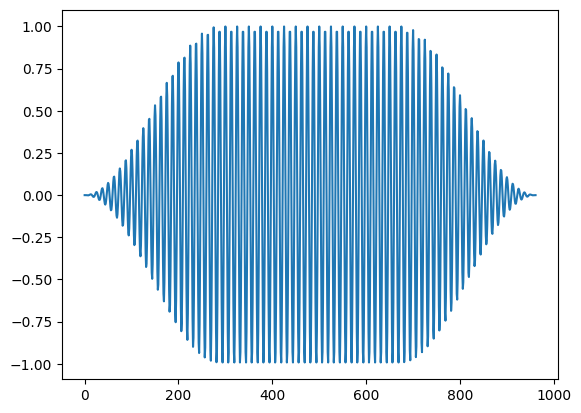

In [8]:
a = schedule.return_pulse_sequence_by_channel()

plt.plot(compile_gates(a["5"]))

### Now we try to add an TD hamitonian with some parameters

In [ ]:
def observable_program_generator(parametrized_H, T, n_sample, n_repetition, diff_var, value, pitime_dict=None):
    """
    Generate parameter-shift branches for differentiating <O> w.r.t. diff_var.

    pitime (π-time for H_j) defaults to π/2, which is correct for normalized
    Pauli operators (eigenvalues ±1): exp(-i·H_j·π/2) = -i·H_j.
    Pass pitime_dict to override per-term.
    """
    returnlist = []
    
    u_grad_dict = parametrized_H.take_diff_coef(diff_var)
    evaluated_H = parametrized_H.set_parameterizedHam({diff_var: value})
    tau_list = np.random.rand(n_sample) * T
    for Hj_tuple in u_grad_dict.keys():
        # π/2 is the correct pitime for normalized Pauli operators
        pitime = np.pi/2 if (pitime_dict is None or Hj_tuple not in pitime_dict) else pitime_dict[Hj_tuple]
        H_tot_list = []
        u_grad = u_grad_dict[Hj_tuple]
        Hj = TIHamiltonian(parametrized_H.sites_type, parametrized_H.sites_name,
                           [(productHamiltonian(from_list=Hj_tuple), 1)])
        evaluated_ugrad = u_grad.subs(diff_var, value)
        for tau in tau_list:
            for sgn in [-1, 1]:
                H_list = []
                H_list.append([evaluated_H, tau])
                H_list.append([Hj, 1 + sgn*3/4*pitime])
                H_list.append([evaluated_H, T - tau])
                H_tot_list.append(H_list)
        info_list = [H_tot_list, evaluated_ugrad, n_repetition]
        returnlist.append(info_list)
    
    # a list of lists: each entry is [H_tot_list, evaluated_ugrad, n_rep]
    return returnlist

In [ ]:
import sympy as sp
x = sp.symbols('x')
theta = sp.symbols('theta')
J0 = sp.sin(2*x + theta)

qs = QSystem()
q = [Qubit(qs) for _ in range(2)]
H = 0
H += J0 *  q[0].Z *  q[1].Z
H += J0 * q[0].X
H += J0 * q[1].X
H += J0 *  q[0].Z *  q[1].Z

H = H.set_parameterizedHam({"theta": np.pi/4 - 0.1})
print(H)

# T=1 keeps dynamics in the perturbative regime where the PSR estimator converges well.
# n_sample=200 gives ~3-4% MC error; use more for tighter estimates.
np.random.seed(42)
T_total = 1.0
listH = observable_program_generator(H, T_total, n_sample=200, n_repetition=1, diff_var="x", value=1.0)
print(f"listH: {len(listH)} Hj term(s), {len(listH[0][0])} H_lists each")

In [7]:
import sympy as sp
x = sp.symbols('x')
theta = sp.symbols('theta')
J0 = sp.sin(2*x+theta)
#print(J0)


qs = QSystem()
q = [Qubit(qs) for _ in range(2)]

for H_int, t in listH[0][0][3]:
    
    #print(H_int,t)
    qs.add_evolution(H_int, t)
qs


Quantum system:
- Sites: Qubit0 Qubit1 
- Sequentially evolves:
    Time = 89.98267143316687,  TIHamiltonian = 0.8810699280503008 * Qubit0.Z * Qubit1.Z  +  0.4405349640251504 * Qubit0.X  +  0.4405349640251504 * Qubit1.X
    Time = 1.75,  TIHamiltonian = 1 * Qubit0.Z * Qubit1.Z
    Time = 10.017328566833129,  TIHamiltonian = 0.8810699280503008 * Qubit0.Z * Qubit1.Z  +  0.4405349640251504 * Qubit0.X  +  0.4405349640251504 * Qubit1.X

In [18]:
from simuq.systems.ising import GenQS
from simuq.braket import diffQCProvider as BraketProvider
awsp = BraketProvider()
awsp.compile(qs, 'quera', 'Aquila', 'rydberg2d', tol=1)
atom_pos = awsp.prog[1]
pulses = awsp.prog[2]
#(i,j) i is instruction type, j is type of hamitlonian:e.g. dressing or gate (kind of buried in the pulse shape of rydberg commands)
#TODO: will need a wrapper on the top of DSL, that handles inst from simqu to awg channel
#e.g. ZZ on 1,3 -> AOD awg moves 1 and 3 to gate zone, then gate awg on with ZZ gate
#TODO: in the instr, native means that it can be together with others, derived cannot, will need to check if dressing is native or derived.
#e.g. gate is definately derived as it will need drag atoms to the gate zone
#TODO: need to add unit so that we know what the pos returned actually means

#TODO: Yuxiang suggests to use sympy to handle the time and other variable part of the hamiltonian, the expression in SIMQU only 
#haneldes the solved global variables or local varibale. E.g. in dressing o is a local varaible that can be solved, maybe d can be a varible handle in sympy
#well, of course for now we just focus on the single qubit case. so that J with sigma_i can be differentiable


for pulse,time in pulses[:1]:
    for p in pulse:
        print(p,time)
pulses

((2, 0), <simuq.qmachine.Instruction object at 0x163f8aad0>, 0.44549077270612614 * Qubit0.X, [0.8909815454122523, -9.204634305639765e-17]) 88.98166993216482
((3, 0), <simuq.qmachine.Instruction object at 0x164324910>, 0.44549077270612825 * Qubit1.X, [0.8909815454122565, 1.0983055842653602e-18]) 88.98166993216482
((5, 0), <simuq.qmachine.Instruction object at 0x164366b30>, 0.8909815460084316 * Qubit0.Z * Qubit1.Z, [0.8909815460084316]) 88.98166993216482


[([((2, 0),
    0.44549077270612614 * Qubit0.X,
    [0.8909815454122523, -9.204634305639765e-17]),
   ((3, 0),
    0.44549077270612825 * Qubit1.X,
    [0.8909815454122565, 1.0983055842653602e-18]),
   ((5, 0),
    0.8909815460084316 * Qubit0.Z * Qubit1.Z,
    [0.8909815460084316])],
  88.98166993216482),
 ([((5, 0),
    1.254297752072982 * Qubit0.Z * Qubit1.Z,
    [1.254297752072982])],
  1.3932338008508283),
 ([((2, 0),
    0.5161868197871168 * Qubit0.X,
    [1.0323736395742336, 3.2754122306060592e-12]),
   ((3, 0),
    0.5161868197474234 * Qubit1.X,
    [1.0323736394948468, 3.275441607364104e-12]),
   ((5, 0),
    1.032455395012795 * Qubit0.Z * Qubit1.Z,
    [1.032455395012795])],
  8.548471946880971)]

In [9]:
pulses

[([((2, 0),
    0.44549077270612614 * Qubit0.X,
    [0.8909815454122523, -9.204634305639765e-17]),
   ((3, 0),
    0.44549077270612825 * Qubit1.X,
    [0.8909815454122565, 1.0983055842653602e-18]),
   ((5, 0),
    0.8909815460084316 * Qubit0.Z * Qubit1.Z,
    [0.8909815460084316])],
  88.98166993216482),
 ([((5, 0),
    1.254297752072982 * Qubit0.Z * Qubit1.Z,
    [1.254297752072982])],
  1.3932338008508283),
 ([((2, 0),
    0.5161868197871168 * Qubit0.X,
    [1.0323736395742336, 3.2754122306060592e-12]),
   ((3, 0),
    0.5161868197474234 * Qubit1.X,
    [1.0323736394948468, 3.275441607364104e-12]),
   ((5, 0),
    1.032455395012795 * Qubit0.Z * Qubit1.Z,
    [1.032455395012795])],
  8.548471946880971)]

In [14]:
import sys
sys.path.append("/Users/syue99/research/RISC-Q/PulseDSL/src/DSL/")
import os
from PulseDSL_py import *
#print(os.path.dirname(PulseDSL_py.__file__))

num_channels = 6
ch, reg = Channels(num_channels)
schedule = Schedule()
set_platform(PulseLib.Rydberg)

x = 2.0

#p1 = Pulse(shape=Shape.Gaussian, amplitude=0.5, duration=5, phase=0.0, beta=0.1)
#p2 = Pulse(shape=Shape.Square, amplitude=0.9, duration=10, phase=0.0)
p = Pulse(shape=Shape.sigmatukey, amplitude=0.8, duration=7, phase=0.0)
#p4 = Pulse(waveform=lambda t: math.exp(-t**2) * cmath.exp(1j * 2 * math.pi * t), duration=10.0)
#p4 = Pulse(shape=Shape.Drag, amplitude=0.6, duration=10, phase=0.0, beta=0.2)



pulse_inst_dictionary = {0:"detuning 0",1:"detuning 1",2:"raman 0",3:"raman 1",4:"global dressing",5:"2qubit gate"}
#function library
#modelling: each channel into a hardware channel, you have a wrapper on the top of this
for pulse,time in pulses:
    length = len(pulse)
    pulse_list = []
    for inst in range(length):
        DSL_pulse = Pulse(shape=Shape.sigmatukey, amplitude=0.8, duration=time*1e3, phase=0.0)
        pulse_list.append(Play(DSL_pulse,ch[pulse[inst][0][0]],is_par=True))
        #print(pulse_inst_dictionary[pulse[inst][0][0]],time)#,parameters)
    #print(pulse_list)
    Parallel(pulse_list)
    #print(length,pulse[0])

    


#Play(p,ch[0])


# for i in range(3):
#   Play(p, ch[0])


# Play(p, ch[1])
# Play(p, ch[2])
#Play(PulseType.X, ch[0])

# Parallel([
#   Play(Pulse(shape=Shape.sigmatukey, amplitude=0.5, duration=400, phase=0.0, beta=0.1), ch[0], is_par=True),
#   Play(Pulse(shape=Shape.sigmatukey, amplitude=0.5, duration=400, phase=0.0, beta=0.1), ch[1], is_par=True),
# ])

# Parallel([
#   Measure(ch[0], is_par=True),
#   Measure(ch[1], is_par=True),
#   Measure(ch[2], is_par=True),
# ])
schedule.view()

#schedule.output()


[PulseDSL] startTime=0, ch=2, amp=0.8, freq=0, phase=0.0, addr=0, dur=88981.66993216482
[PulseDSL] startTime=0, ch=3, amp=0.8, freq=0, phase=0.0, addr=0, dur=88981.66993216482
[PulseDSL] startTime=0, ch=5, amp=0.8, freq=0, phase=0.0, addr=0, dur=88981.66993216482
[PulseDSL] startTime=88981.66993216482, ch=5, amp=0.8, freq=0, phase=0.0, addr=0, dur=1393.2338008508282
[PulseDSL] startTime=90374.90373301564, ch=2, amp=0.8, freq=0, phase=0.0, addr=0, dur=8548.47194688097
[PulseDSL] startTime=90374.90373301564, ch=3, amp=0.8, freq=0, phase=0.0, addr=0, dur=8548.47194688097
[PulseDSL] startTime=90374.90373301564, ch=5, amp=0.8, freq=0, phase=0.0, addr=0, dur=8548.47194688097

----------
Schedule view:
----------

Schedule for channel 0:
No entries

Schedule for channel 1:
No entries

Schedule for channel 2:
- sigmatukey amp=0.8 dur=88981.66993216482 phase=0.0 from 0 to 88981.66993216482
- sigmatukey amp=0.8 dur=8548.471946880978 phase=0.0 from 90374.90373301564 to 98923.37567989662

Schedule

- language/
|- channel.py
|- core.py
|- ops.py
|- schedule.py
- hardware
|- scqubit.py
|- rydberg.py
|- ...
- library
|- calibration.py
|- rydberg/
|- scqubit/
 |- qiskit.json
 |- ...
- parser // qasm to Pulse DSL
|- parser.py

In [15]:
a = schedule.return_pulse_sequence_by_channel()
print(a["4"])
#plt.plot(compile_gates(a["4"]))

[]


In [17]:
pulse_inst_dictionary = {0:"detuning 0",1:"detuning 1",2:"raman 0",3:"raman 1",5:"2qubit gate",4:"global dressing"}
#function library
for pulse,time in pulses:
    length = len(pulse)
    pulse_list = []
    for inst in range(length):
        DSL_pulse = Pulse(shape=Shape.sigmatukey, amplitude=0.8, duration=time*1e3, phase=0.0)
        pulse_list.append(Play(DSL_pulse,ch[pulse[inst][0][0]],is_par=True))
        print(pulse_inst_dictionary[pulse[inst][0][0]],time)#,parameters)
    #print(pulse_list)
    #Parallel(pulse_list)

raman 0 88.98166993216482
raman 1 88.98166993216482
2qubit gate 88.98166993216482
2qubit gate 1.3932338008508283
raman 0 8.548471946880971
raman 1 8.548471946880971
2qubit gate 8.548471946880971


In [6]:
import qiskit

In [103]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator,StatevectorSimulator
from qiskit import transpile
# Create a 3-qubit circuit
qc = QuantumCircuit(3,3)

# Apply Toffoli gate
# Controls: qubit 0 and 1
# Target: qubit 2
#qc.h(2)
qc.h(0)
qc.h(1)

qc.ccx(0, 1, 2)

qc.s(2)
qc.ccx(0, 1, 2)
qc.h(0)
qc.h(1)
# qc.z(2)
#qc.h(2)
# Add measurements
#qc.measure([0, 1, 2], [0, 1, 2],)

# Use local simulator
#simulator = AerSimulator()
simulator = StatevectorSimulator(precision='single')
# Transpile for simulator
compiled_circuit = transpile(qc, simulator)

# Run simulation
job = simulator.run(compiled_circuit, shots=100)

# Get results
result = job.result()
counts = result.get_counts()
# Draw the circuit
print(qc.draw(),counts)

     ┌───┐               ┌───┐
q_0: ┤ H ├──■─────────■──┤ H ├
     ├───┤  │         │  ├───┤
q_1: ┤ H ├──■─────────■──┤ H ├
     └───┘┌─┴─┐┌───┐┌─┴─┐└───┘
q_2: ─────┤ X ├┤ S ├┤ X ├─────
          └───┘└───┘└───┘     
c: 3/═════════════════════════
                               {'000': 100}


In [104]:

from qiskit.quantum_info import Statevector

psi = Statevector(compiled_circuit)

In [105]:
print(psi)
psi.draw('latex')

Statevector([ 0.75+0.25j,  0.25-0.25j,  0.25-0.25j, -0.25+0.25j,
              0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ],
            dims=(2, 2, 2))


<IPython.core.display.Latex object>

In [14]:
# #Test sympy evaluation function
# x = sp.symbols('x')
# theta = sp.symbols('theta')
# J0 = sp.sin(2*x+theta)
# J0 = J0.subs(x, 2)
# J0 = J0.subs(theta, 0)
# float(J0)

In [15]:
# x = sp.symbols('x')
# theta = sp.symbols('theta')
# J0 = sp.sin(2*x+theta)
# J0 = J0.subs(x, 0.3)
# #make it a lambda function
# f = sp.lambdify(theta, J0, "numpy")
# f(1)


In [16]:
# import sympy as sp

# # Define symbols
# x, y = sp.symbols('x y')

# # Define symbolic expression
# f1 = x**2 + sp.sin(y)

# # Lambdify
# #f_num = sp.lambdify((x,y), f, 'numpy')

# # Call it
# f_x_only = lambda x_val: f_num(x_val, 0.3)
# f_x_only

# x = sp.symbols('x')
# theta = sp.symbols('theta')
# J0 = sp.sin(2*x+theta)
# J0 = J0.subs(x, 0.3)
# #make it a lambda function
# f = sp.lambdify(theta, J0, "numpy")
# f(1)

### DiffSimuQ — End-to-End Gradient (Steps 1-3)

Wire `QuTiPSequentialRunner` + `combine_gradient_results` into the existing `listH` from `observable_program_generator`,
then validate the gradient estimate against finite differences.

In [ ]:
# Step 1: Wire QuTiPSequentialRunner
import sys
sys.path.insert(0, "/Users/syue99/research/SimuQ/differential_computing/")
from qutip_sequential import QuTiPSequentialRunner

runner = QuTiPSequentialRunner(n_qubits=2)
psi0   = runner.zero_state()
obs    = runner.zz_observable(0, 1)          # measure ZZ on qubits 0,1
expfn  = runner.make_expectation_fn(psi0, obs)

# Quick sanity check: run a single H_list from listH
# listH[j] = [H_tot_list, evaluated_ugrad, n_rep]
# H_tot_list[0] = first H_list (sgn=-1 for first tau)
test_H_list = listH[0][0][0]
val = expfn(test_H_list)
print(f"Sanity check — <ZZ> after test sequence: {val:.6f}")

In [ ]:
# Step 2: Compute gradient via combine_gradient_results
from combine_gradient import combine_gradient_results

diff_var_val = 1.0
grad_estimate = combine_gradient_results(listH, expfn, T=T_total)
print(f"Gradient estimate  d<ZZ>/dx  at x={diff_var_val}, T={T_total}:  {grad_estimate:.6f}")

In [ ]:
# Step 3: Validate against finite differences
import qutip as qp

def f_at_x(x_val, T_eval=T_total):
    """<ZZ> expectation for the base Hamiltonian evaluated at x=x_val."""
    J_expr = sp.sin(2*sp.Symbol('x') + sp.Symbol('theta'))
    qs_fd = QSystem()
    q_fd  = [Qubit(qs_fd) for _ in range(2)]
    H_fd  = J_expr*q_fd[0].Z*q_fd[1].Z + J_expr*q_fd[0].X + J_expr*q_fd[1].X + J_expr*q_fd[0].Z*q_fd[1].Z
    H_eval = H_fd.set_parameterizedHam({"theta": np.pi/4 - 0.1, "x": x_val})
    psi_fd = qp.tensor([qp.basis(2, 0)] * 2)
    result = qp.sesolve(H_eval.to_qutip_qobj(), psi_fd, [0, float(T_eval)])
    return float(qp.expect(obs, result.states[-1]).real)

eps = 1e-4
fd_grad = (f_at_x(diff_var_val + eps) - f_at_x(diff_var_val - eps)) / (2 * eps)
print(f"Finite-difference   d<ZZ>/dx  at x={diff_var_val}:  {fd_grad:.6f}")
print(f"Parameter-shift est d<ZZ>/dx  at x={diff_var_val}:  {grad_estimate:.6f}")
print(f"Relative error: {abs(grad_estimate - fd_grad) / (abs(fd_grad) + 1e-12):.3%}")